## Week 2 Day 2 - Orchestration

Our first Agentic Framework project!!

### Part 1: Email Setup

### Part 2: Orchestrating by code

### Part 3: Orchestrating by LLMs

- 3a: via Tools
- 3b: via Handoffs

## Part 1: Email Setup

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">IMPORTANT PLEASE READ - Sending Emails</h2>
            <span style="color:#ff7800;">We are going to write an agent that sends emails. The best way to do this is with an email provider
            like SendGrid or Resend. But this requires a fair amount of heavy-lifting: you need to send from a proper email host where you own the domain and you can prove it with DNS records. It's quite a hassle.<br/><br/>
            So we're going to do it the free & simple way: using SMTP server configuration to send direct from your email. It's an easy setup, but it's not as powerful (eg you can't receive emails). If you'd like to take this further, use SendGrid or Resend instead..<br/><br/>
            And actually the email send is optional. We're doing this to demonstrate an Agent sending emails. The important part is the Agent work, not the email sending. Feel free to swap out the function for a Pushover push if you'd prefer.
            </span>
        </td>
    </tr>
</table>

## Setting up to send emails from your SMTP server

### Using AWS SES



In [ ]:
from dotenv import load_dotenv
import requests
from agents import Agent, Runner, trace, function_tool, ModelSettings
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
import os
import asyncio
import smtplib
from email.message import EmailMessage
load_dotenv(override=True)
MODEL_NAME = "gpt-5.4-mini"

In [ ]:
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")
EMAIL_SMTP_SERVER = os.getenv("EMAIL_SMTP_SERVER")
EMAIL_APP_PASSWORD = os.getenv("EMAIL_APP_PASSWORD")

if EMAIL_ADDRESS:
    print("Email address is set")
else:
    print("Email address is not set")

if EMAIL_SMTP_SERVER:
    print("SMTP server is set")
else:
    print("SMTP server is not set")

if EMAIL_APP_PASSWORD:
    print("App password is set")
else:
    print("App password is not set")

USE_EMAIL = EMAIL_ADDRESS and EMAIL_SMTP_SERVER and EMAIL_APP_PASSWORD

if USE_EMAIL:
    print("Email is set up and we will try using it")
else:
    print("Email is not set up; we will send push notifications instead")

In [ ]:
# Here we go

def send_email(subject, text_body, html_body):
    msg = EmailMessage()
    msg["From"] = EMAIL_ADDRESS
    msg["To"] = EMAIL_ADDRESS
    msg["Subject"] = subject
    msg.set_content(text_body)
    msg.add_alternative(html_body, subtype="html")

    with smtplib.SMTP(EMAIL_SMTP_SERVER, 587) as server:
        server.starttls()
        server.login(EMAIL_ADDRESS, EMAIL_APP_PASSWORD)
        server.send_message(msg)

In [ ]:
send_email("Testing testing 123", "Fingers crossed..", "<html><body><strong>Fingers</strong> crossed..</body></html>")

### If this didn't work, then uncomment the below so that we don't use emails

In [ ]:
# USE_EMAIL = False

### Our fallback strategy - send a push

In [ ]:
pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

if pushover_user:
    if pushover_user.startswith("u"):
        print("Pushover user found and looks good")
    else:
        print("Pushover user found but doesn't start with u")
else:
    print("Pushover user not found")

if pushover_token:
    if pushover_token.startswith("a"):
        print("Pushover token found and looks good")
    else:
        print("Pushover token found but doesn't start with a")
else:
    print("Pushover token not found")

In [ ]:
def push(message):
    print(f"Push: {message}")
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)

In [ ]:
def send_message(subject, text_body, html_body):
    if USE_EMAIL:
        send_email(subject, text_body, html_body)
    else:
        push(f"Subject: {subject}\n\n{text_body}")

### OK Now everything should work!

In [ ]:
send_message("Big news", "Communications are a go!", "<html><body>Communications are a <strong>go!</strong></body></html>")

## Agent Orchestration

There are 2 models for Agent Orchestration; by code and by LLMs.

By code: more predictable and deterministic.

By LLMs: more powerful.

An excellent write-up is here:

https://openai.github.io/openai-agents-python/multi_agent/

We will start with by Code.

In [11]:
#import smtplib
#from email.message import EmailMessage

MODEL_NAME = "gpt-5.4-mini"


from dotenv import load_dotenv
from agents import Agent, Runner, trace, function_tool, ModelSettings
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
from typing import Dict
# import sendgrid
import boto3
from botocore.exceptions import ClientError

import re
import os
#from sendgrid.helpers.mail import Mail, Email, To, Content
import asyncio

load_dotenv(override=True)

aws_region = os.getenv("AWS_REGION", "eu-central-1")
aws_profile = os.getenv("AWS_PROFILE", "default")
EMAIL_SENDER = os.getenv("SES_FROM_EMAIL")
EMAIL_RECIPIENT = os.getenv("SES_TO_EMAIL")

In [12]:
def send_basic_email(
    sender: str,
    recipient: str,
    subject: str,
    body_text: str,
    aws_region: str,
) -> str:

    ses = boto3.client("ses", region_name=aws_region)

    response = ses.send_email(
        Source=sender,
        Destination={
            "ToAddresses": [recipient],
        },
        Message={
            "Subject": {
                "Data": subject,
                "Charset": "UTF-8",
            },
            "Body": {
                "Text": {
                    "Data": body_text,
                    "Charset": "UTF-8",
                },
            },
        },
    )

def send_test_email():
    sender = EMAIL_SENDER
    recipient = EMAIL_RECIPIENT
    subject = "Test mail from agent-tutorial"
    body_text = (
        "Hello,\n\n"
        "This is test mail from my agent-tutorial.\n\n"
        "Cheers,\n"
        "agent-tutorial-bot"
    )
    try:
        message_id = send_basic_email(
            sender=sender,
            recipient=recipient,
            subject=subject,
            body_text=body_text,
            aws_region=aws_region,
        )
    except ClientError as error:
        print("Failed to send email.")
        print(error.response["Error"]["Code"])
        print(error.response["Error"]["Message"])
        return 1

    print(f"Email sent. Message ID: {message_id}")
    return 0
    

send_test_email()

Email sent. Message ID: None


0

## Part 2: Orchestrating by Code

In [13]:
intro = """
You are a sales agent working for ;-)mabstruct, 
a company that provides physical semantic AI solutions for intelligent robotics, powered by AI.
You write emails.
"""

instructions1 = intro + "Your email style is professional, serious, with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of a busy senior executive."

In [14]:
sales_agent1 = Agent(name="Professional Sales Agent", instructions=instructions1, model=MODEL_NAME)
sales_agent2 = Agent(name="Humorous Sales Agent", instructions=instructions2, model=MODEL_NAME)
sales_agent3 = Agent(name="Executive Sales Agent", instructions=instructions3, model=MODEL_NAME)


In [15]:

result = Runner.run_streamed(sales_agent1, input="Write a cold sales email")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

Subject: A practical path to intelligent robotics

Hi [First Name],

I’m reaching out from ;-)mabstruct, where we build physical semantic AI solutions for intelligent robotics.

We help teams move beyond perception alone and enable systems that can understand context, reason about their environment, and act with greater reliability in real-world settings. For organizations working in robotics, automation, or advanced machine interaction, this can mean faster deployment, improved operational consistency, and more capable autonomous behavior.

If this is relevant to your current roadmap, I’d welcome the chance to share how we approach it and explore whether there may be a fit.

Would you be open to a brief call next week?

Best regards,  
[Your Name]  
[Title]  
;-)mabstruct  
[Email] | [Phone] | [Website]

In [16]:
message = "Write a cold sales email"

with trace("Parallel cold emails"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )

outputs = [result.final_output for result in results]

for output in outputs:
    print(output + "\n\n")


Subject: Physical Semantic AI for more capable robotics

Hello [First Name],

I’m reaching out from ;-)mabstruct, where we develop physical semantic AI solutions for intelligent robotics.

In short, we help robotics teams move beyond perception alone and toward systems that can better interpret, organize, and act on real-world physical environments with greater reliability.

If your team is exploring ways to improve robotic understanding, adaptability, or task execution in complex settings, I would welcome a brief conversation to see whether there is a fit.

Would you be open to a 15-minute call next week?

Best regards,  
[Your Name]  
[Title] | ;-)mabstruct  
[Email] | [Phone] | [Website]


Subject: Your robots called. They’d like better brains.  

Hi [First Name],  

I’ll keep this short, because robots, like humans, generally prefer not to sit through a bad pitch.  

At ;-)mabstruct, we build **physical semantic AI solutions** for intelligent robotics — the kind that help machines 

In [20]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Do not give an explanation; reply with the selected email only.
"""

sales_picker = Agent(name="Sales_picker", instructions=decision, model=MODEL_NAME)


In [21]:
message = "Write a cold sales email"

with trace("Sales selection workflow"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    print(emails)

Cold sales emails:

Subject: Bringing Physical Semantic AI to Your Robotics Stack

Hi [First Name],

I’m reaching out from ;-)mabstruct because we help robotics teams move beyond perception alone and into **physical semantic AI**—systems that can understand environments, objects, and tasks with greater operational intelligence.

In practice, this means giving intelligent robots a stronger foundation for:
- interpreting real-world context,
- improving task execution,
- and supporting more reliable autonomy in dynamic environments.

Our approach is designed for teams that need AI grounded in physical reality, not just digital inference.

If this is relevant to your roadmap, I’d welcome the opportunity to share how ;-)mabstruct is helping robotics organizations build more capable systems.

Would you be open to a brief call next week?

Best regards,  
[Your Name]  
[Title]  
;- )mabstruct  
[Email] | [Phone] | [Website]

Email:

Subject: Your robots deserve better than “guess and pray”  



In [22]:
best = await Runner.run(sales_picker, emails)

print(f"Best sales email:\n{best.final_output}")


Best sales email:
Email:

Subject: Physical Semantic AI for robotics

Hi [First Name],

I’m reaching out from ;-)mabstruct. We provide physical semantic AI solutions for intelligent robotics — helping systems better understand and act in the real world.

If you’re working on robotics, automation, or embodied AI, I’d welcome a brief conversation to see whether this is relevant.

Open to a 15-minute call next week?

Best,  
[Your Name]  
 ;-)mabstruct


Now go and check out the trace:

https://platform.openai.com/traces

### Now we will add a tool to the mix.

In [ ]:
@function_tool
def send_email_tool(subject: str, text_body: str, html_body: str) -> str:
    """
    Send out an email with the given subject and body to all sales prospects
    
    Args:
        subject: The subject of the email
        text_body: The body of the email as plain text
        html_body: The HTML body of the email
    """
    send_message(subject, text_body, html_body)
    return "Email sent successfully"

In [30]:
@function_tool
def send_html_email(
    subject: str,
    body_html: str,
    ) -> str:

    def html_to_basic_text(html: str) -> str:
        text = re.sub(r"<br\s*/?>", "\n", html, flags=re.IGNORECASE)
        text = re.sub(r"</p\s*>", "\n\n", text, flags=re.IGNORECASE)
        text = re.sub(r"<[^>]+>", "", text)
        return text.strip()
    
    ses = boto3.client("ses", os.getenv("AWS_REGION"))
    response = ses.send_email(
        Source=EMAIL_SENDER,
        Destination={
            "ToAddresses": [os.getenv("SES_TO_EMAIL")],
        },
        Message={
            "Subject": {
                "Data": subject,
                "Charset": "UTF-8",
            },
            "Body": {
                "Text": {
                    "Data": html_to_basic_text(body_html),
                    "Charset": "UTF-8",
                },
                "Html": {
                    "Data": body_html,
                    "Charset": "UTF-8",
                },
            },
        },
    )

### This has automatically been converted into a tool, with the boilerplate json created

In [31]:
send_html_email.params_json_schema

{'properties': {'subject': {'title': 'Subject', 'type': 'string'},
  'body_html': {'title': 'Body Html', 'type': 'string'}},
 'required': ['subject', 'body_html'],
 'title': 'send_html_email_args',
 'type': 'object',
 'additionalProperties': False}

In [32]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Then use your tool to send the email.
"""

require_tool = ModelSettings(tool_choice="required")

sales_sender = Agent(name="Sales Sender", instructions=decision, model=MODEL_NAME, tools=[send_html_email], model_settings=require_tool)

In [33]:
message = "Write a cold sales WITH EMAIL"

with trace("Sales selection workflow with sending"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    response = await Runner.run(sales_sender, emails)

    print(f"Final response:\n{response.final_output}")

Final response:
Done — I chose the third email and sent it.


### Did that work?!

See the traces for more! This is a great way to debug. Smaller models might require more time and experimentation.

https://platform.openai.com/traces

## Part 3: Orchestrating by LLMs

### 3a: via Tools

The simplest way to have 1 Agent choose to invoke another is by treating it as a tool call.

The OpenAI Agents SDK gives a very simple way to do this.

This works best when the flow is:

Agent A -> Agent B -> Agent A

And for the classic "Planning Agent" situation.

In [38]:
description1 = "Use this tool to write a professional sales email. In the input, just instruct it to write a sales email."
description2 = "Use this tool to write a humorous sales email. In the input, just instruct it to write a sales email."
description3 = "Use this tool to write an executive-style sales email. In the input, just instruct it to write a sales email."

tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool1

FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x116f234d0>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False)

### So now we can gather all the tools together:

A tool for each of our 3 email-writing agents

And a tool for our function to send emails

In [39]:
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_professional", tool_description=description1)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_humorous", tool_description=description2)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_executive", tool_description=description3)

tools = [tool1, tool2, tool3, send_html_email]

tools

[FunctionTool(name='sales_email_writer_professional', description='Use this tool to write a professional sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x117263bc0>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False),
 FunctionTool(name='sales_email_writer_humorous', description='Use this tool to write a humorous sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'proper

## And now it's time for our Sales Manager - our planning agent

In [40]:
instructions = """
You are a Sales Manager at ;-)mabstruct. Your goal is to find the single best cold sales email using the sales_writer tools.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Evaluate and Select: Review the drafts and choose the single best email using your judgment of which one is most effective.
 
3. Use your tool to send the best email (and only the best email) to the user. Only send 1 email.
"""

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model=MODEL_NAME)


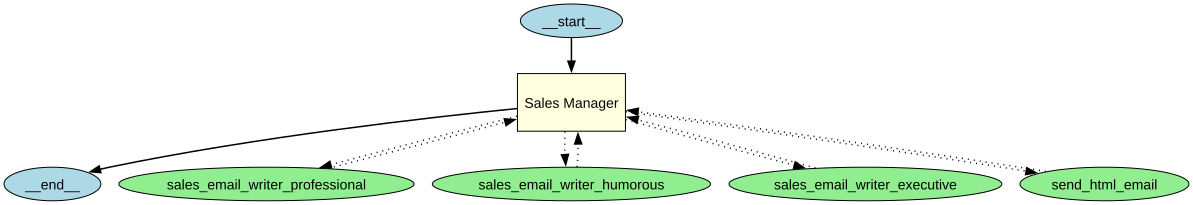

In [41]:
draw_graph(sales_manager)

In [42]:
with trace("SALES MANAGER mabstrcut"):
    result = await Runner.run(sales_manager, task)

## Remember to check the trace

https://platform.openai.com/traces

And then check your email!! Also look in your Junk / Spam folder - after all, this is basically a spam message..


<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Unreliable results?</h2>
            <span style="color:#ff7800;">This is par for the course with Agentic AI, and particularly with Orchestrating by LLM.
            To resolve it, you'll need to experiment and iterate with the prompts. Particularly with smaller models, more experiments
            may be needed to get reliable outcomes.
            </span>
        </td>
    </tr>
</table>

## Part 3: Orchestrating by LLMs

### 3a: via Handoffs

I am not a fan of handoffs. They seem very unreliable. They're not used consistently by other frameworks.

Behind the scenes, OpenAI Agents SDK has implemented these with Tools anyway.

### Handoffs represent a way an agent can delegate to an agent, passing control to it

Handoffs and Agents-as-tools are similar:

In both cases, an Agent can collaborate with another Agent

With tools, control passes back

A -> B -> A

With handoffs, control passes across

A -> B

In [45]:

instructions = """
You are a Sales Manager at ComplAI. You get your sales team to draft emails, then send them all to a sales picker.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Handoff to the sales sender to choose and send the best email.
"""

tools = [tool1, tool2, tool3]
handoffs = [sales_sender]

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, handoffs=handoffs, model=MODEL_NAME)


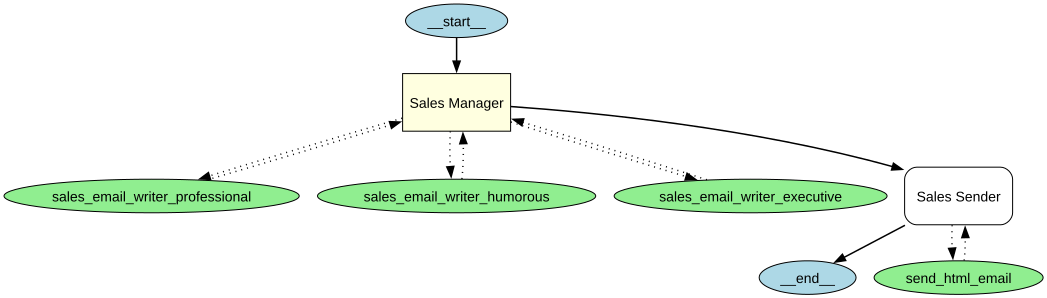

In [44]:
draw_graph(sales_manager)

In [46]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)

Tool name 'transfer_to_Sales Sender' contains invalid characters for function calling and has been transformed to 'transfer_to_sales_sender'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Sales Sender' contains invalid characters for function calling and has been transformed to 'transfer_to_sales_sender'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Sales Sender' contains invalid characters for function calling and has been transformed to 'transfer_to_sales_sender'. Please use only letters, digits, and underscores to avoid potential naming conflicts.


### Remember to check the trace

https://platform.openai.com/traces

And then check your email!!

Note that handoffs can be unrealiable and a little bit frustrating. I needed to force the tool use otherwise this didn't work. If you don't get reliable behavior, try iterating on the prompts - or use a larger model. And enjoy the process; this is what Agentic AI is all about!

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">Try extending with some more orchestration - perhaps another iteration of the email to refine it. 
            Use Orchestrating via Code and Orchestrating via LLMs.  
            HARD CHALLENGE: switch to using a professional email provider like SendGrid or Resend. Then handle the user replying. 
            Then have the SDR respond to keep the conversation going!
            </span>
        </td>
    </tr>
</table>

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/business.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#00bfff;">Commercial implications</h2>
            <span style="color:#00bfff;">This is immediately applicable to Sales Automation; but more generally this could be applied to  end-to-end automation of any business process through conversations and tools. Think of ways you could apply an Agent solution
            like this in your day job.
            </span>
        </td>
    </tr>
</table>